Import required libraries

In [ ]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet   
from sklearn.model_selection import KFold

Data loading and standardization

In [2]:
X_raw = np.loadtxt("dataF_final.csv", delimiter=",")
Y_raw = np.loadtxt("dataC_final.csv", delimiter=",")

if Y_raw.ndim == 1:
    Y_raw = Y_raw.reshape(-1, 1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X_raw)
Y = scaler_y.fit_transform(Y_raw)

Cross-validated RMSE for subset evaluation

Used inside the CARS algorithm to track the optimal subset

In [3]:
def cv_rmse(X, y, n_components=20):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    comp = min(n_components, X.shape[1], X.shape[0]-1)
    model = PLSRegression(n_components=comp)

    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))

    return np.mean(rmses)

Competitive Adaptive Reweighted Sampling (CARS)

Steps:
1. Fit PLS model
2. Rank variables using regression coefficients
3. Apply exponential decreasing function (EDF)
4. Iteratively remove low-importance variables
5. Select subset minimizing CV-RMSE

In [4]:
def cars_selection(X, y_single, n_iter=80):

    n_samples, n_features = X.shape
    idx = np.arange(n_features)
    best_subset = idx.copy()
    min_rmse = float('inf')

    p0 = 1.0
    pmin = 2 / n_features
    a = np.power(pmin, 1/(n_iter-1))
    k = (np.log(p0) - np.log(pmin)) / (n_iter - 1)

    for i in range(n_iter):
        Xs = X[:, idx]

        n_comp = min(20, Xs.shape[1], Xs.shape[0]-1)
        pls = PLSRegression(n_components=n_comp)
        pls.fit(Xs, y_single)

        weights = np.abs(pls.coef_.flatten())

        current_rmse = cv_rmse(Xs, y_single)
        if current_rmse < min_rmse:
            min_rmse = current_rmse
            best_subset = idx.copy()

        ratio = a * np.exp(-k * (i + 1))
        num_to_keep = max(2, int(np.round(n_features * ratio)))

        norm_weights = weights / np.sum(weights)
        sorted_indices = np.argsort(-norm_weights)
        idx = idx[sorted_indices[:num_to_keep]]

        if len(idx) <= 2:
            break

    return best_subset

Regression models and cross-validation

In [6]:
results_list = []
all_predictions = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_models = {
    "PLSR": PLSRegression(n_components=20),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.0001),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.001)
}


Model evaluation using 5-fold cross-validation


In [8]:

print(f"{'Target':<8} | {'Model':<12} | {'R2_test':<10} | {'RMSE_test':<10} | {'Features':<8}")
print("-" * 75)

for t in range(Y.shape[1]):
    print(f"\nOptimizing Target {t+1}...")
    start = time.time()

    best_idx = cars_selection(X, Y[:,t])
    X_selected = X[:, best_idx]
    y_target = Y[:, t]

    fold_scores = {name: {"r2": [], "rmse": []} for name in test_models}
    temp_true = {name: [] for name in test_models}
    temp_pred = {name: [] for name in test_models}

    for train_idx, test_idx in kf.split(X_selected):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_target[train_idx], y_target[test_idx]

        for name, model in test_models.items():

            if name == "PLSR":
                model.n_components = min(20, X_selected.shape[1])

            model.fit(X_train, y_train)
            pred = model.predict(X_test).flatten()

            temp_true[name].extend(y_test)
            temp_pred[name].extend(pred)

            fold_scores[name]["r2"].append(r2_score(y_test, pred))
            fold_scores[name]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))

    for name in test_models:
        mean_r2 = np.mean(fold_scores[name]["r2"])
        mean_rmse = np.mean(fold_scores[name]["rmse"])

        results_list.append({
            "Target": t+1,
            "Model": name,
            "R2_test": mean_r2,
            "RMSE_test": mean_rmse,
            "Features": len(best_idx)
        })

        all_predictions[(t+1, name)] = (
            np.array(temp_true[name]),
            np.array(temp_pred[name])
        )

        print(f"T{t+1:<6} | {name:<12} | {mean_r2:.4f} | {mean_rmse:.4f} | {len(best_idx):<8}")

    print(f"RunTime: {time.time() - start:.2f}s")

Target   | Model        | R2_test    | RMSE_test  | Features
---------------------------------------------------------------------------

Optimizing Target 1...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.676e-01, tolerance: 2.025e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.244e+00, tolerance: 2.025e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.677e-01, tolerance: 2.1

T1      | PLSR         | 0.9338 | 0.2532 | 234     
T1      | Ridge        | 0.9241 | 0.2692 | 234     
T1      | Lasso        | 0.8037 | 0.4291 | 234     
T1      | ElasticNet   | 0.9260 | 0.2673 | 234     
RunTime: 6.16s

Optimizing Target 2...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.925e-01, tolerance: 2.065e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.188e+00, tolerance: 2.065e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.469e-01, tolerance: 2.0

T2      | PLSR         | 0.9426 | 0.2377 | 234     
T2      | Ridge        | 0.9367 | 0.2497 | 234     
T2      | Lasso        | 0.8906 | 0.3260 | 234     
T2      | ElasticNet   | 0.9395 | 0.2441 | 234     
RunTime: 6.74s

Optimizing Target 3...


...

c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.832e-01, tolerance: 1.964e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.119e+00, tolerance: 1.964e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.513e-01, tolerance: 1.8

T4      | PLSR         | 0.9426 | 0.2308 | 278     
T4      | Ridge        | 0.9346 | 0.2502 | 278     
T4      | Lasso        | 0.8498 | 0.3779 | 278     
T4      | ElasticNet   | 0.9317 | 0.2536 | 278     
RunTime: 6.98s

Optimizing Target 5...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.659e-01, tolerance: 2.275e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.834e+00, tolerance: 2.275e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.414e-01, tolerance: 1.3

T5      | PLSR         | 0.8661 | 0.3026 | 197     
T5      | Ridge        | 0.8210 | 0.3492 | 197     
T5      | Lasso        | 0.6196 | 0.4954 | 197     
T5      | ElasticNet   | 0.8523 | 0.3218 | 197     
RunTime: 6.11s


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.722e-01, tolerance: 2.302e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.089e+00, tolerance: 2.302e-02
  model = cd_fast.enet_coordinate_descent(


Best Model Per Target (CARS)

In [9]:
results_df_cars = pd.DataFrame(results_list)

best_models_cars = (
    results_df_cars.sort_values("RMSE_test")
    .groupby("Target")
    .first()
    .reset_index()
)

best_models_cars

,Target,Model,R2_test,RMSE_test,Features
0,1,PLSR,0.933772,0.253159,234
1,2,PLSR,0.942631,0.237672,234
2,3,PLSR,0.939470,0.224370,303
3,4,PLSR,0.942607,0.230752,278
4,5,PLSR,0.866069,0.302601,197


Predicted vs Observed for best model per target

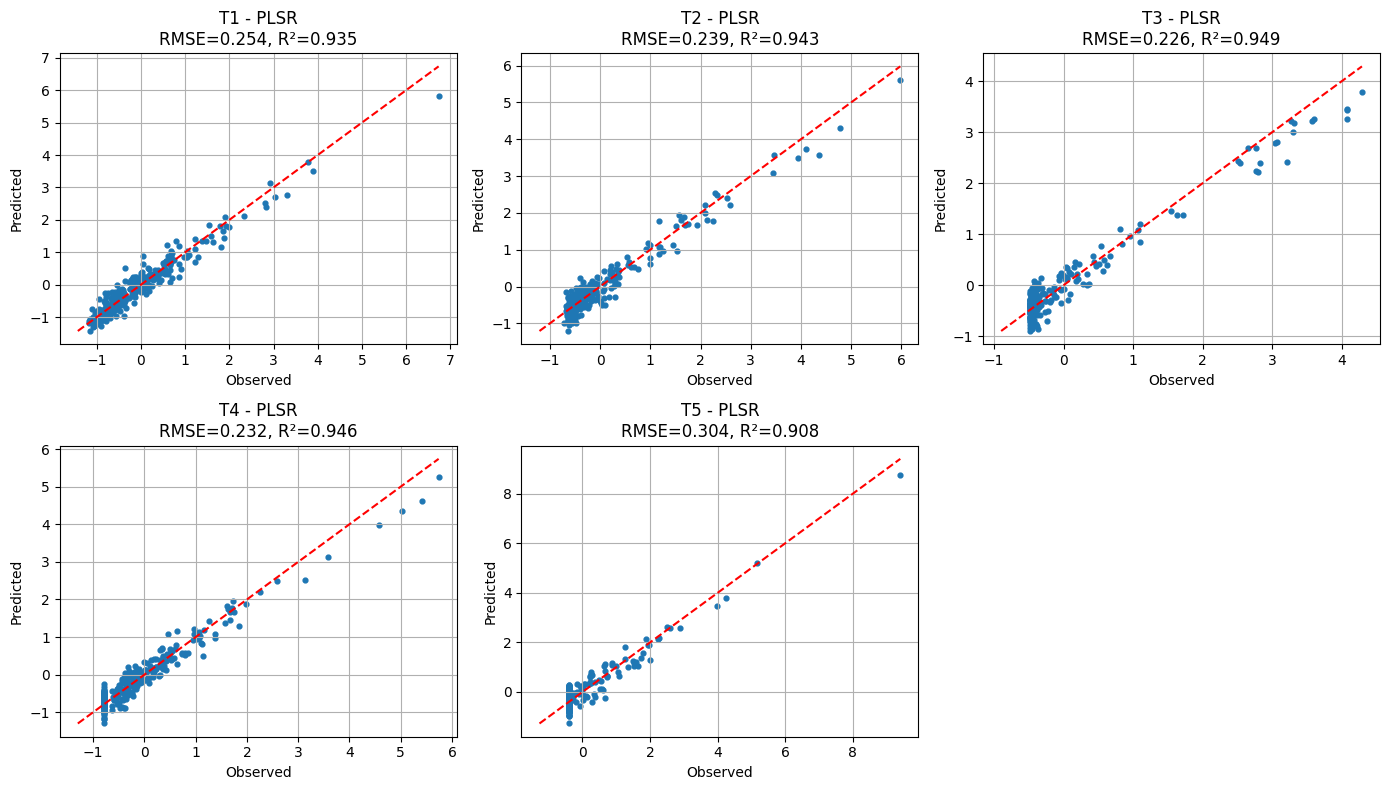

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def plot_best_models(best_models, all_predictions):
    
    cols = 3
    rows = int(np.ceil(len(best_models) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for i, row in best_models.iterrows():
        t = row["Target"]
        model = row["Model"]

        y_true, y_pred = all_predictions[(t, model)]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        plt.subplot(rows, cols, i + 1)
        plt.scatter(y_true, y_pred, s=12)

        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        plt.plot([min_v, max_v], [min_v, max_v], "r--")

        plt.title(f"T{t} - {model}\nRMSE={rmse:.3f}, R²={r2:.3f}")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        plt.grid()

    plt.tight_layout()
    plt.show()
    
plot_best_models(best_models_cars, all_predictions)